<a href="https://colab.research.google.com/github/ShrutiP-16/Task1/blob/main/NL_Amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Amazon**: **Improving Fulfillment** **Efficiency**





**Business Context**  :

Amazon handles millions of orders daily across product categories and fulfillment methods.
As order volume scales, operational efficiency becomes critical. A high number of orders does
not guarantee success if a significant portion results in cancellations or returns.

Improving fulfillment efficiency helps Amazon reduce logistics costs, improve customer
satisfaction, and strengthen long-term platform trust.

**Problem Statement:**

Despite high order volumes, not all placed orders successfully convert into delivered revenue.
Cancellations, returns, and refunds create fulfillment leakage, increase operational costs, and reduce customer satisfaction.

Amazon needs a data-driven understanding of where and why fulfillment failures occur across products, customers, and logistics dimensions.

This analysis aims to answer the following key questions:
1. What proportion of total orders fail to reach successful delivery?
2. Which order statuses contribute most to fulfillment inefficiency?
3. Which product categories, subcategories, and brands drive higher cancellations and returns?
4. How do logistics choices such as shipping method and payment method impact fulfillment outcomes?
5. How do product attributes like ratings, reviews, stock levels, and pricing relate to fulfillment performance?


# **Objective**

To identify the key drivers of Fulfillment Efficiency loss at Amazon and recommend data-backed actions to improve realized revenue and reduce cancellations, returns, and refunds.
In large-scale e-commerce platforms such as Amazon or Flipkart, fulfillment efficiency directly impacts customer satisfaction, operational costs, and revenue. Order cancellations and product returns introduce inefficiencies in the supply chain, leading to lost revenue, increased reverse logistics costs, and reduced customer trust.

This project aims to analyze fulfillment efficiency by examining order success rates, cancellation rates, return rates, and associated revenue loss across product categories to identify key inefficiency drivers and improvement opportunities.

***

- Define and deconstruct the Fulfillment Efficiency metric into actionable sub-metrics.
- Identify products, categories, and logistics combinations that drive:
  - high delivered revenue,
  - high cancellations,
  - high returns and refunds.
- Analyze the relationship between product attributes and fulfillment outcomes.
- Surface actionable insights that can help Amazon improve catalog quality, reduce fulfillment risk, and increase realized revenue.


In [1]:
 #Install gdown
!pip install gdown

# Analysis And Visualisations

In [2]:
import gdown
import pandas as pd    # For data manipulation and analysis
import numpy as np       # For numerical computations
import matplotlib.pyplot as plt   # For plotting and visualization
import seaborn as sns     # For advanced visualizations

**Loading Dataset From Google Drive**

In [3]:
# Google Drive file ID
fileid1="1asL0c0lKsgD7dKW8YFsKxsX3PlJcINr3"
# Construct the file's download URL
download_url1 = f"https://drive.google.com/uc?id={fileid1}"


In [4]:
# Set the output file name
outputfile1="order.csv"

In [5]:
# Download the file
gdown.download(download_url1, outputfile1, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1asL0c0lKsgD7dKW8YFsKxsX3PlJcINr3
From (redirected): https://drive.google.com/uc?id=1asL0c0lKsgD7dKW8YFsKxsX3PlJcINr3&confirm=t&uuid=9bb1a556-ea3c-4216-8f19-9804e976ff90
To: /content/order.csv
100%|██████████| 377M/377M [00:08<00:00, 45.6MB/s]


'order.csv'

In [6]:
# Load the dataset directly from Google Drive
order_df = pd.read_csv(outputfile1,sep=';')

**Viewing the First  Rows of the Order Dataset**

In [7]:
print("First 5 Rows of the Dataset:")
print(order_df.head())

First 5 Rows of the Dataset:
   order_id  person_id  order_date      status payment_method shipping_method  \
0         1     422330  2024-11-11    Returned    credit_card         express   
1         2     537703  2025-09-21    Returned      apple_pay           fedex   
2         3     336716  2023-10-30   Cancelled         klarna           fedex   
3         4     583679  2023-09-24     Shipped     debit_card             ups   
4         5     284565  2022-09-06  Processing         paypal             dhl   

                             notes  total_amount  
0                              NaN      20966.47  
1                              NaN       9495.94  
2                              NaN      21560.10  
3  Do not leave in direct sunlight      21732.49  
4                              NaN      11731.89  


**Loading Orderline Dataset From Google Drive**

In [8]:
#Loading orderline dataset
# Google Drive file ID
fileid2="17ILcJjbjeEn3V8XXVCbcCnHDD1OSkyMc"
# Construct the file's download URL
download_url2 = f"https://drive.google.com/uc?id={fileid2}"


In [9]:
# Set the output file name
outputfile2="orderline.csv"

In [10]:
# Download the file
gdown.download(download_url2, outputfile2, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=17ILcJjbjeEn3V8XXVCbcCnHDD1OSkyMc
From (redirected): https://drive.google.com/uc?id=17ILcJjbjeEn3V8XXVCbcCnHDD1OSkyMc&confirm=t&uuid=95c3b6b0-af07-43f3-887f-065c18197ce4
To: /content/orderline.csv
100%|██████████| 642M/642M [00:15<00:00, 42.2MB/s]


'orderline.csv'

In [11]:
# Load the dataset directly from Google Drive
orderline_df = pd.read_csv(outputfile2,sep=';')

**Viewing the First Few Rows of the OrderLine Dataset**

In [12]:
print("First 5 Rows of the Dataset:")
print(orderline_df.head())

First 5 Rows of the Dataset:
   order_id  orderline_id  product_id  quantity  unit_price  subtotal  \
0   4806362             2        6427         9     1061.95   9557.55   
1   3645950             1        2771         2      884.33   1768.66   
2    381606             1        4174         1     1228.99   1228.99   
3   1791846             1        4182         9     1608.99  14480.91   
4   3388824             1        1086         4      723.95   2895.80   

      status                            notes  
0    pending                              NaN  
1  cancelled                              NaN  
2    shipped  Return conditions per item only  
3   returned                              NaN  
4    pending                              NaN  


**Loading Person Dataset From Google Drive**

In [13]:
#Loading person dataset
# Google Drive file ID
fileid3="1wC4_70mSrnfMTreq4r_tN-t_vnF-FNMH"
# Construct the file's download URL
download_url3 = f"https://drive.google.com/uc?id={fileid3}"

In [14]:
# Set the output file name
outputfile3="person.csv"

In [15]:
# Download the file
gdown.download(download_url3, outputfile3, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1wC4_70mSrnfMTreq4r_tN-t_vnF-FNMH
To: /content/person.csv
100%|██████████| 83.3M/83.3M [00:01<00:00, 42.9MB/s]


'person.csv'

In [16]:
# Load the dataset directly from Google Drive
person_df = pd.read_csv(outputfile3,sep=';')

**Viewing the First Few Rows of the Person Dataset**

In [17]:
print("First 5 Rows of the Dataset:")
print(person_df.head())

First 5 Rows of the Dataset:
   person_id firstname lastname  gender  age             street  streetnumber  \
0          1   Bethany    Perez   Other   40     Rodriguez Ford           962   
1          2  Clarence    Peavy  Female   72     Zachary Forest          1742   
2          3      Erik   Morgan   Other   48       Rose Highway          2180   
3          4    Jerome   Murphy  Female   84  Wright Throughway          1735   
4          5     Vicki     Pell    Male   64        James Lakes          1536   

  address_unit  postalcode                  city           phone  \
0     Room 476       56337       Port Karlaville  1-987-330-7101   
1   Unit 1734C       75083        Katelynborough    900-397-4581   
2    Apt. 261V       76285          Dylanchester    683-596-8728   
3    Floor 459       96211      Port Ernestmouth  (282) 723-3027   
4    Floor 227       84536  East Jenniferchester  (480) 866-9040   

                        email  
0         pebble8@example.com  
1  henry_ma

**Loading Product Dataset From Google Drive**

In [18]:
#Loading product dataset
# Google Drive file ID
fileid4="1oP6YBidR1CG-hWL0J8qfwf9xWxqMHi57"
# Construct the file's download URL
download_url4 = f"https://drive.google.com/uc?id={fileid4}"

In [19]:
# Set the output file name
outputfile4="product.csv"

In [20]:
# Download the file
gdown.download(download_url4, outputfile4, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1oP6YBidR1CG-hWL0J8qfwf9xWxqMHi57
To: /content/product.csv
100%|██████████| 1.75M/1.75M [00:00<00:00, 76.0MB/s]


'product.csv'

In [21]:
# Load the dataset directly from Google Drive
product_df = pd.read_csv(outputfile4,sep=';')

**Viewing the First Few Rows of the Product Dataset**

In [22]:
print("First 5 Rows of the Dataset:")
print(product_df.head())

First 5 Rows of the Dataset:
   product_id             sku                          name  \
0           1  PRD-KMQL4V-KEE        Cutting Monitor Deluxe   
1           2  PRD-VD0TAJ-NBG              Elite Phablet v3   
2           3  PRD-7Y1LDD-PGW         Refined FlagshipPhone   
3           4  PRD-71U6RH-SUS  Authentic WearableCamera Kit   
4           5  PRD-LDJV55-JOS                 Windbreaker L   

                                         description        category  \
0     Trendy design reflecting current market trends  Mobile Devices   
1        Elegant aesthetics with minimalist approach       Reference   
2      Sophisticated design for discerning customers         Organic   
3  Simple setup requires minimal technical knowledge          eBooks   
4        Artistic design combining form and function     Formal Wear   

  subcategory         brand    price     cost  stock_quantity  weight_kg  \
0      RidOns    RoastRoyal   181.95    79.95             440      43.46   
1    Ut

**Checking the Shape of the Order Dataset**

In [23]:
rows, columns = order_df.shape
print(f"The Orders dataset contains {rows} rows and {columns} columns.")


The Orders dataset contains 5000000 rows and 8 columns.


**Checking the Shape of Orderline Dataset**

In [24]:
rows, columns = orderline_df.shape
print(f"The Orders dataset contains {rows} rows and {columns} columns.")

The Orders dataset contains 13000000 rows and 8 columns.


**Checking the Shape of Person Dataset**

In [25]:
rows, columns = person_df.shape
print(f"The Orders dataset contains {rows} rows and {columns} columns.")

The Orders dataset contains 600000 rows and 12 columns.


**Checking the Shape of Product Dataset**

In [26]:
rows, columns = product_df.shape
print(f"The Orders dataset contains {rows} rows and {columns} columns.")

The Orders dataset contains 8000 rows and 18 columns.


**Displaying Order Dataset Information**

In [27]:
print("\nDataset Information:")
order_df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   order_id         int64  
 1   person_id        int64  
 2   order_date       object 
 3   status           object 
 4   payment_method   object 
 5   shipping_method  object 
 6   notes            object 
 7   total_amount     float64
dtypes: float64(1), int64(2), object(5)
memory usage: 305.2+ MB


**Displaying Orderline Dataset Information**

In [28]:
print("\nDataset Information:")
orderline_df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000000 entries, 0 to 12999999
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   order_id      int64  
 1   orderline_id  int64  
 2   product_id    int64  
 3   quantity      int64  
 4   unit_price    float64
 5   subtotal      float64
 6   status        object 
 7   notes         object 
dtypes: float64(2), int64(4), object(2)
memory usage: 793.5+ MB


**Displaying Person Dataset Information**

In [29]:
print("\nDataset Information:")
person_df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   person_id     600000 non-null  int64 
 1   firstname     600000 non-null  object
 2   lastname      600000 non-null  object
 3   gender        600000 non-null  object
 4   age           600000 non-null  int64 
 5   street        600000 non-null  object
 6   streetnumber  600000 non-null  int64 
 7   address_unit  539589 non-null  object
 8   postalcode    600000 non-null  int64 
 9   city          600000 non-null  object
 10  phone         600000 non-null  object
 11  email         600000 non-null  object
dtypes: int64(4), object(8)
memory usage: 54.9+ MB


**Displaying Product Dataset Information**

In [30]:
print("\nDataset Information:")
product_df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      8000 non-null   int64  
 1   sku             8000 non-null   object 
 2   name            8000 non-null   object 
 3   description     8000 non-null   object 
 4   category        8000 non-null   object 
 5   subcategory     8000 non-null   object 
 6   brand           8000 non-null   object 
 7   price           8000 non-null   float64
 8   cost            8000 non-null   float64
 9   stock_quantity  8000 non-null   int64  
 10  weight_kg       8000 non-null   float64
 11  length_cm       8000 non-null   float64
 12  width_cm        8000 non-null   float64
 13  height_cm       8000 non-null   float64
 14  status          8000 non-null   object 
 15  created_date    8000 non-null   object 
 16  rating_average  8000 non-null   float64
 17  review_coun

In [31]:
# Converting 'order_date' from object (string) to datetime for proper date-based analysis
order_df['order_date'] = pd.to_datetime(order_df['order_date'], errors='coerce')
#checking the data type of order_date column after conversion
print(order_df['order_date'].dtype)



datetime64[ns]


In [32]:
# Converting created_date in product dataset from object(string) to datetime for proper analysis

product_df['created_date'] = pd.to_datetime(product_df['created_date'], errors='coerce')
#checking the data type of created_date column after conversion
print(product_df['created_date'].dtype)


datetime64[ns]


In [33]:
## Data Validation: Order Total vs Order Line Total
# Validate order total vs orderline total
orderline_sum = orderline_df.groupby("order_id")["subtotal"].sum().reset_index()
validation = order_df.merge(orderline_sum, on="order_id", how="left")
validation["difference"] = validation["total_amount"] - validation["subtotal"]

validation["difference"].abs().describe()


,difference
count,5.000000e+06
mean,3.546614e-13
std,1.046772e-12
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,1.455192e-11


**Observation:**

The difference between order totals and aggregated order line subtotals is effectively zero. Minor deviations are due to floating-point precision. This confirms strong data consistency between ORDER and ORDERLINE tables.


**Checking For The Missing Values**

In [34]:
#checking missing values in order dataset
missing_values_in_order = order_df.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values_in_order)
#checking missing values in orderline dataset
missing_values_in_orderline = orderline_df.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values_in_orderline)
#checking missing values in person dataset
missing_values_in_person = person_df.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values_in_person)
#checking missing values in product dataset
missing_values_in_product = product_df.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values_in_product)


Missing Values in Each Column:
order_id                 0
person_id                0
order_date               0
status                   0
payment_method           0
shipping_method          0
notes              4750689
total_amount             0
dtype: int64

Missing Values in Each Column:
order_id               0
orderline_id           0
product_id             0
quantity               0
unit_price             0
subtotal               0
status                 0
notes           12350097
dtype: int64

Missing Values in Each Column:
person_id           0
firstname           0
lastname            0
gender              0
age                 0
street              0
streetnumber        0
address_unit    60411
postalcode          0
city                0
phone               0
email               0
dtype: int64

Missing Values in Each Column:
product_id        0
sku               0
name              0
description       0
category          0
subcategory       0
brand             0
price        

**Missing Value Handling Observations:**

Missing values are primarily observed in address-related fields and notes columns across PERSON and ORDER datasets. These attributes do not influence fulfillment efficiency and were retained without imputation.  

Missing values in product ratings and review counts indicate newly listed products and were included to preserve realistic business scenarios. No critical transactional fields contained missing values.


**Handling The Missing Values In All 4 Datasets**

In [35]:
# 1. order_df: 'notes' column has many missing values (~95% of rows)
# Reason: 'notes' is optional textual information. Filling with 'NA' retains all orders
# while clearly marking missing notes.
order_df['notes'] = order_df['notes'].fillna('NA')

# 2️. orderline_df: 'notes' column also has many missing values (~95% of rows)
# Reason: Optional textual information. Filling with 'NA' ensures dataset completeness
# without affecting numeric or key columns.
orderline_df['notes'] = orderline_df['notes'].fillna('NA')

# 3️. person_df: 'address_unit' column has missing values (~10%)
# Reason: Some customers do not have unit/apartment numbers. Filling with 'NA'
# maintains completeness and avoids issues during merging.
person_df['address_unit'] = person_df['address_unit'].fillna('NA')

# 4.product_df: No missing values detected
# Reason: Dataset is complete; no action required.


**Data Cleaning Decisions**

Missing values were analyzed across all datasets with a focus on their relevance to fulfillment efficiency and revenue-related metrics.

Optional, non-critical fields such as address_unit and free-text notes contained missing values and were retained without imputation beyond placeholder labeling, as they do not influence order outcomes or financial calculations.

No missing values were observed in critical transactional fields including order identifiers, order status, quantities, or monetary values. As a result, no order or order line records required removal to preserve the integrity of fulfillment efficiency metrics.

Data types were preserved to maintain transactional accuracy and ensure consistency during aggregation and analysis.


**Distribution & Outlier Assessment**

**Order Total Amount Distribution**

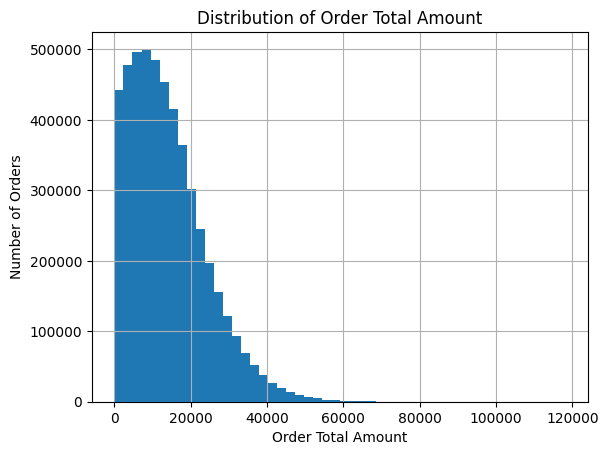

In [36]:
import matplotlib.pyplot as plt

plt.figure()
order_df["total_amount"].hist(bins=50)
plt.title("Distribution of Order Total Amount")
plt.xlabel("Order Total Amount")
plt.ylabel("Number of Orders")
plt.show()



**Observation:**

The distribution of order total amount is right-skewed, with most orders concentrated in the lower to mid-value range.
A small number of high-value orders create a long tail, representing bulk or premium purchases.
These outliers were retained as they reflect genuine customer purchasing behavior and are important for revenue analysis.


**Quantity per Order Line Distribution**

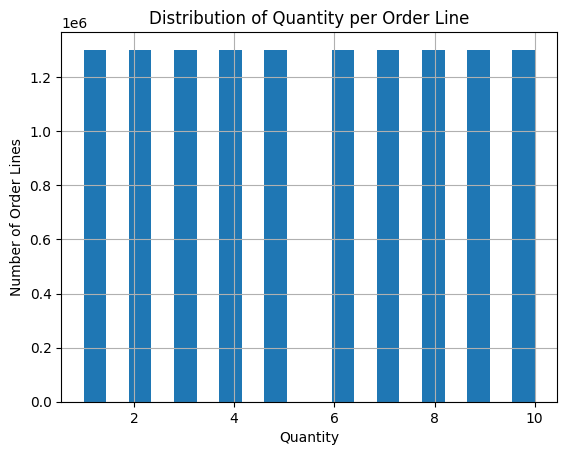

In [37]:
plt.figure()
orderline_df["quantity"].hist(bins=20)
plt.title("Distribution of Quantity per Order Line")
plt.xlabel("Quantity")
plt.ylabel("Number of Order Lines")
plt.show()


**Observation**:

The quantity per order line ranges from 1 to 10 and shows an almost uniform distribution.
This indicates controlled purchase limits and absence of extreme or unrealistic values.
Since no anomalous behavior is observed, the quantity data was retained without outlier treatment.


**Summary Of Dataset Observations**

In [38]:
# Purpose: After handling missing values, we want to summarize the dataset to ensure it is clean
# and ready for analysis. This step checks for two things:
# 1️⃣ Duplicate rows: Identifies if any rows are repeated in the dataset.
# 2️⃣ Missing values: Confirms that all missing values have been handled.

# Steps:
# - Count the number of duplicate rows using duplicated().sum()
# - Count missing values in each column using isnull().sum()
# - Print observations based on these counts to document dataset status
# - This provides clarity and shows reviewers that the dataset is ready for further analysis

# ===========================================================
# Dataset Summary: Checking for Duplicates and Missing Values for All 4 Datasets
# ===========================================================

# Purpose: After handling missing values, we summarize all datasets to ensure they are clean
# and ready for further analysis. This step checks for:
# 1️⃣ Duplicate rows: Identifies if any rows are repeated in the dataset.
# 2️⃣ Missing values: Confirms that all missing values have been handled.

datasets = {
    'order_df': order_df,
    'orderline_df': orderline_df,
    'person_df': person_df,
    'product_df': product_df
}

for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()  # Count duplicate rows
    missing_values = df.isnull().sum()       # Count missing values per column

    print(f"\nObservations About {name}:")

    # Check for duplicate rows
    if duplicate_count > 0:
        print(f"- There are {duplicate_count} duplicate rows in the dataset.")
    else:
        print("- No duplicate rows found in the dataset.")

    # Check for missing values
    if missing_values.sum() > 0:
        print("- There are missing values in the dataset. Here’s a summary:")
        print(missing_values[missing_values > 0])
    else:
        print("- No missing values found in the dataset.")

    print("- The dataset is ready for further analysis after handling duplicates and missing values.")




Observations About order_df:
- No duplicate rows found in the dataset.
- No missing values found in the dataset.
- The dataset is ready for further analysis after handling duplicates and missing values.

Observations About orderline_df:
- No duplicate rows found in the dataset.
- No missing values found in the dataset.
- The dataset is ready for further analysis after handling duplicates and missing values.

Observations About person_df:
- No duplicate rows found in the dataset.
- No missing values found in the dataset.
- The dataset is ready for further analysis after handling duplicates and missing values.

Observations About product_df:
- No duplicate rows found in the dataset.
- No missing values found in the dataset.
- The dataset is ready for further analysis after handling duplicates and missing values.


### Data Quality Summary

- No duplicate records were found across PERSON, ORDER, ORDERLINE, and PRODUCT tables, ensuring one-to-one integrity where expected.
- No critical missing values were observed in key analytical fields such as order status, pricing, quantity, and product attributes.
- This confirms that the dataset is structurally sound and suitable for reliable fulfillment efficiency and revenue analysis.


# **2.DataTypes**

In [39]:
# Displaying column names for all datasets to understand available variables
datasets = {
    "order": order_df,
    "orderline": orderline_df,
    "person": person_df,
    "product": product_df
}

for name, df in datasets.items():
    print(f"\nColumns in {name}:")
    print(df.columns.tolist())



Columns in order:
['order_id', 'person_id', 'order_date', 'status', 'payment_method', 'shipping_method', 'notes', 'total_amount']

Columns in orderline:
['order_id', 'orderline_id', 'product_id', 'quantity', 'unit_price', 'subtotal', 'status', 'notes']

Columns in person:
['person_id', 'firstname', 'lastname', 'gender', 'age', 'street', 'streetnumber', 'address_unit', 'postalcode', 'city', 'phone', 'email']

Columns in product:
['product_id', 'sku', 'name', 'description', 'category', 'subcategory', 'brand', 'price', 'cost', 'stock_quantity', 'weight_kg', 'length_cm', 'width_cm', 'height_cm', 'status', 'created_date', 'rating_average', 'review_count']


In [40]:
# Summary of Dataset Statistics
datasets = {
    "Order Dataset": order_df,
    "Orderline Dataset": orderline_df,
    "Person Dataset": person_df,
    "Product Dataset": product_df
}

for name, df in datasets.items():
    print(f"\n===== Summary Statistics for {name} =====")
    print(df.describe(include='all'))



===== Summary Statistics for Order Dataset =====
            order_id     person_id                     order_date     status  \
count   5.000000e+06  5.000000e+06                        5000000    5000000   
unique           NaN           NaN                            NaN          7   
top              NaN           NaN                            NaN  Cancelled   
freq             NaN           NaN                            NaN     715293   
mean    2.500000e+06  2.999135e+05  2023-06-07 01:43:32.833921024        NaN   
min     1.000000e+00  1.000000e+00            2021-01-01 00:00:00        NaN   
25%     1.250001e+06  1.498530e+05            2022-03-21 00:00:00        NaN   
50%     2.500000e+06  2.999110e+05            2023-06-07 00:00:00        NaN   
75%     3.750000e+06  4.498960e+05            2024-08-24 00:00:00        NaN   
max     5.000000e+06  6.000000e+05            2025-11-10 00:00:00        NaN   
std     1.443376e+06  1.732671e+05                            NaN     

In [41]:
#Variable Description
print("\n### Variables Description ###")
variable_description={
    "Order_Dataset":{
        "order_id":"unique ID for each order",
        "person_id" : "ID of the customer placing the order",
        "order_date":"date when the order was placed",
        "status":"order status(Fulfilled,Cancelled)",
        "payment_method":"payment method used to place the order",
        "shipping_method":"shipping method selected by customers(express,economy)",
        "notes":"any additional notes ",
        "total_amount":"total amount of the order",
    },
    "Orderline_Dataset":{
        "order_id":"identifier of the order to which the line item belongs",
        "orderline_id": "Unique ID for each line item",
        "product_id": "ID of the product",
        "quantity": "Number of units ordered",
        "unit_price": "Price per unit",
        "subtotal": "Total price for this line item",
        "status": "Status of the line item",
        "notes": "Any additional notes"
    },
    "Person_Dataset":{
         "person_id": "Unique ID for each customer",
        "firstname": "First name of the customer",
        "lastname": "Last name of the customer",
        "gender": "Gender of the customer",
        "age": "Age of the customer",
        "street": "Street name",
        "streetnumber": "Street number",
        "address_unit": "Apartment or unit number",
        "postalcode": "Postal code",
        "city": "City of residence",
        "phone": "Contact number",
        "email": "Email address"
    },
    "Product_Dataset":{
        "product_id": "Unique ID for each product",
        "sku": "Stock keeping unit",
        "name": "Product name",
        "description": "Product description",
        "category": "Product category",
        "subcategory": "Product subcategory",
        "brand": "Brand of the product",
        "price": "Selling price",
        "cost": "Cost price",
        "stock_quantity": "Number of units in stock",
        "weight_kg": "Weight in kilograms",
        "length_cm": "Length in cm",
        "width_cm": "Width in cm",
        "height_cm": "Height in cm",
        "status": "Product availability status",
        "created_date": "Date when product was added",
        "rating_average": "Average rating",
        "review_count": "Number of reviews"
    }
}
for dataset, columns in variable_description.items():
    print(f"\n### Variables Description for {dataset} ###")
    for col, desc in columns.items():
        print(f"* **{col}**: {desc}")


### Variables Description ###

### Variables Description for Order_Dataset ###
* **order_id**: unique ID for each order
* **person_id**: ID of the customer placing the order
* **order_date**: date when the order was placed
* **status**: order status(Fulfilled,Cancelled)
* **payment_method**: payment method used to place the order
* **shipping_method**: shipping method selected by customers(express,economy)
* **notes**: any additional notes 
* **total_amount**: total amount of the order

### Variables Description for Orderline_Dataset ###
* **order_id**: identifier of the order to which the line item belongs
* **orderline_id**: Unique ID for each line item
* **product_id**: ID of the product
* **quantity**: Number of units ordered
* **unit_price**: Price per unit
* **subtotal**: Total price for this line item
* **status**: Status of the line item
* **notes**: Any additional notes

### Variables Description for Person_Dataset ###
* **person_id**: Unique ID for each customer
* **firstnam

**Unique Values for each variable.**

In [42]:
datasets = {
    "Order Dataset": order_df,
    "Orderline Dataset": orderline_df,
    "Person Dataset": person_df,
    "Product Dataset": product_df
}

print("### Unique Values for Each Variable ###")
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    for column in df.columns.tolist():  # **indent this inside outer loop**
        print(f"No. of unique values in {column}: {df[column].nunique()}")


### Unique Values for Each Variable ###

--- Order Dataset ---
No. of unique values in order_id: 5000000
No. of unique values in person_id: 599866
No. of unique values in order_date: 1775
No. of unique values in status: 7
No. of unique values in payment_method: 7
No. of unique values in shipping_method: 8
No. of unique values in notes: 14
No. of unique values in total_amount: 2069026

--- Orderline Dataset ---
No. of unique values in order_id: 5000000
No. of unique values in orderline_id: 12
No. of unique values in product_id: 8000
No. of unique values in quantity: 10
No. of unique values in unit_price: 199593
No. of unique values in subtotal: 449481
No. of unique values in status: 5
No. of unique values in notes: 16

--- Person Dataset ---
No. of unique values in person_id: 600000
No. of unique values in firstname: 655
No. of unique values in lastname: 164
No. of unique values in gender: 3
No. of unique values in age: 73
No. of unique values in street: 49995
No. of unique values in st

Unique value checks were performed to validate expected categorical levels and ensure there are no unexpected or inconsistent labels that could distort fulfillment efficiency calculations.


# 3. **Data Wrangling**

**Data Wrangling Code**

In [43]:
# Copying the dataset for analysis
# Copying the datasets to create working copies for analysis,this ensures that the original datasets remain unchanged
df1 = order_df.copy()
df2=orderline_df.copy()
df3=person_df.copy()
df4=product_df.copy()

In [44]:
#checking the basic stats
print("Order Dataset Shape:", df1.shape)
print("Orderline Dataset Shape:",df2.shape)
print("Person Dataset Shape:",df3.shape)
print("Product Dataset Shape:",df4.shape)


# checking columns
print("\nOrder Dataset Columns:", df1.columns)
print("\nOrderline Dataset Columns:", df2.columns)
print("\nPerson Columns:", df3.columns)
print("\nProduct Dataset Columns:", df4.columns)

Order Dataset Shape: (5000000, 8)
Orderline Dataset Shape: (13000000, 8)
Person Dataset Shape: (600000, 12)
Product Dataset Shape: (8000, 18)

Order Dataset Columns: Index(['order_id', 'person_id', 'order_date', 'status', 'payment_method',
       'shipping_method', 'notes', 'total_amount'],
      dtype='object')

Orderline Dataset Columns: Index(['order_id', 'orderline_id', 'product_id', 'quantity', 'unit_price',
       'subtotal', 'status', 'notes'],
      dtype='object')

Person Columns: Index(['person_id', 'firstname', 'lastname', 'gender', 'age', 'street',
       'streetnumber', 'address_unit', 'postalcode', 'city', 'phone', 'email'],
      dtype='object')

Product Dataset Columns: Index(['product_id', 'sku', 'name', 'description', 'category', 'subcategory',
       'brand', 'price', 'cost', 'stock_quantity', 'weight_kg', 'length_cm',
       'width_cm', 'height_cm', 'status', 'created_date', 'rating_average',
       'review_count'],
      dtype='object')


# **Key Business Metrics:**


1.**Fulfillment Efficiency:**



Fulfillment Efficiency = Net Realized Revenue ÷ Gross Order Value

In [45]:
#key metrics:Fulfillment Efficiency
#As defined in the problem statement, Fulfillment Efficiency is measured using a revenue-based lens to capture how much of the gross order value is successfully realized after accounting for fulfillment failures.
#definition:Fulfillment Efficiency is defined as the ratio of Net Realized Revenue (NRR) to Gross Order Value (GOV).
#Gross Order Value (GOV): Total value of all orders placed on the platform.
#Net Realized Revenue (NRR): Revenue from delivered orders minus revenue lost due to returns and refunds.
#formula :Fulfillment Efficiency = Net Realized Revenue ÷ Gross Order Value
#Fulfillment Efficiency indicates how much of the total order value was successfully realized after considering delivered vs returned/refunded orders.

Gross_Order_Value = order_df['total_amount'].sum()

# Positive revenue statuses
positive_revenue = order_df.loc[
    order_df['status'].isin(['Delivered', 'Shipped', 'Processing', 'Pending']),
    'total_amount'
].sum()
#Cancelled orders are excluded from NRR calculations as they do not contribute to realized revenue.
# Negative revenue statuses (exclude cancelled)
negative_revenue = order_df.loc[
    order_df['status'].isin(['Returned', 'Refunded']),
    'total_amount'
].sum()

# Net Realized Revenue
Net_Realized_Revenue = positive_revenue - negative_revenue

# Fulfillment Efficiency
Fulfillment_Efficiency = Net_Realized_Revenue / Gross_Order_Value

print(f"GOV: {Gross_Order_Value:,.2f}")
print(f"NRR: {Net_Realized_Revenue:,.2f}")
print(f"Fulfillment Efficiency: {Fulfillment_Efficiency:.2%}")


GOV: 70,376,452,551.13
NRR: 20,065,259,544.96
Fulfillment Efficiency: 28.51%


While Fulfillment Efficiency is defined using revenue realization, it is influenced
by multiple operational outcomes such as deliveries, cancellations, returns, and
refunds. Therefore, supporting operational metrics are analysed alongside the core
metric to understand the underlying drivers of efficiency.

**Interpretation:**

The Fulfillment Efficiency ratio indicates how much of the total order value is
successfully realized after accounting for fulfillment failures such as returns,
refunds, and cancellations.

In [46]:
# Supporting Metrics:
#To interpret and explain Fulfillment Efficiency, the following supporting metrics are analysed:
order_level_df = (
    order_df
    .groupby('order_id', as_index=False)
    .agg(
        status=('status', 'first'),
        total_amount=('total_amount', 'first'),
        payment_method=('payment_method', 'first'),
        shipping_method=('shipping_method', 'first')
    )
)

order_level_df.head()
total_orders = order_level_df['order_id'].nunique()
#Order Success Rate: Measures the proportion of orders that successfully reach customers. A low success rate directly reduces realized revenue
order_success_rate = (order_level_df['status'] == 'Delivered').mean()
#Cancellation Rate: Indicates demand loss before fulfillment, often linked to inventory or payment issues.
cancellation_rate = (order_level_df['status'] == 'Cancelled').mean()
#Return Rate: Captures post-delivery dissatisfaction, increasing reverse-logistics costs.
return_rate = (order_level_df['status'] == 'Returned').mean()
#Refund Rate: Reflects monetary leakage after order completion.
refund_rate = (order_level_df['status'] == 'Refunded').mean()
#Average Order Value (AOV): Helps assess whether higher-value orders carry greater fulfillment risk.
#Average Order Value (AOV) represents the average demand per order placed, including cancelled orders, as it is calculated using Gross Order Value
AOV = order_level_df['total_amount'].mean()

print(f"Total Orders: {total_orders}")
print(f"Order Success Rate: {order_success_rate:.2%}")
print(f"Cancellation Rate: {cancellation_rate:.2%}")
print(f"Return Rate: {return_rate:.2%}")
print(f"Refund Rate: {refund_rate:.2%}")
print(f"AOV: {AOV:,.2f}")


Total Orders: 5000000
Order Success Rate: 14.28%
Cancellation Rate: 14.31%
Return Rate: 14.29%
Refund Rate: 14.29%
AOV: 14,075.29


**Interpretation:**

Supporting metrics were calculated at the order level using unique order_id values
to avoid double counting caused by multiple records per order.

In [47]:
# Items per Order:Items per Order helps identify large orders and contributes to understanding fulfillment efficiency at the order level.
items_per_order = orderline_df.groupby('order_id').size().reset_index(name='items_count')
print("Sample Items per Order:")
print(items_per_order.head())
## Average Items per Order (supporting metric)
avg_items_per_order = items_per_order['items_count'].mean()
avg_items_per_order

Sample Items per Order:
   order_id  items_count
0         1            2
1         2            2
2         3            3
3         4            6
4         5            2


np.float64(2.6)

**Interpretation:**
Items per Order is calculated at the orderline level to capture order
complexity. Higher item counts per order can increase fulfillment effort,
logistics handling, and the likelihood of partial returns, thereby impacting
overall Fulfillment Efficiency. The average items per order is used as a
supporting KPI, while the distribution is analyzed in EDA.

In [48]:
# Return-Adjusted Margin (Proxy for Profitability):is a proxy profitability metric that estimates net margin after fulfillment by offsetting delivered-order margins with margin losses from returns and refunds.
# In Positive Profit: we have included fulfilled ,shipped and pending order lines
# Step 1: Merge orderline with product cost
orderline_master = orderline_df.merge(
    product_df[['product_id', 'cost']],
    on='product_id',
    how='left'
)

# Step 2: Calculate margin per order line
orderline_master['margin'] = (
    orderline_master['unit_price'] - orderline_master['cost']
) * orderline_master['quantity']

# Step 3: Positive profit
# Fulfilled, Shipped, Pending
positive_margin = orderline_master.loc[
    orderline_master['status'].isin(['fulfilled', 'shipped', 'pending']),
    'margin'
].sum()

# Step 4: Loss due to returns
returned_margin = orderline_master.loc[
    orderline_master['status'] == 'returned',
    'margin'
].sum()

# Step 5: Return-Adjusted Margin
return_adjusted_margin = positive_margin - returned_margin

# Step 6: Output
print(f"Positive Profit (Fulfilled + Shipped + Pending): {positive_margin:,.2f}")
print(f"Returned Loss: {returned_margin:,.2f}")
print(f"Return-Adjusted Margin (Proxy): {return_adjusted_margin:,.2f}")


Positive Profit (Fulfilled + Shipped + Pending): 9,736,360,520.53
Returned Loss: 3,254,314,177.68
Return-Adjusted Margin (Proxy): 6,482,046,342.85


**Operational Drivers of Fulfillment Efficiency**

To further understand the factors influencing Fulfillment Efficiency, the
existing metrics were analyzed across key operational dimensions. This section
does not introduce new KPIs but examines how fulfillment performance varies
across product categories and order complexity levels.

In [49]:
# Fulfillment Efficiency by Shipping Method

# Step 1: Gross Order Value (GOV)
gov_by_shipping = (
    order_df
    .groupby('shipping_method')['total_amount']
    .sum()
)

# Step 2: Positive realized revenue
positive_revenue_shipping = (
    order_df
    .loc[order_df['status'].isin(['Delivered', 'Shipped', 'Processing', 'Pending'])]
    .groupby('shipping_method')['total_amount']
    .sum()
)

# Step 3: Revenue loss due to returns and refunds
negative_revenue_shipping = (
    order_df
    .loc[order_df['status'].isin(['Returned', 'Refunded'])]
    .groupby('shipping_method')['total_amount']
    .sum()
)

# Step 4: Net Realized Revenue (NRR)
nrr_by_shipping = positive_revenue_shipping - negative_revenue_shipping
nrr_by_shipping = nrr_by_shipping.fillna(0)

# Step 5: Fulfillment Efficiency
fulfillment_efficiency_shipping = (
    nrr_by_shipping / gov_by_shipping
).reset_index(name='fulfillment_efficiency')

# Final output
fulfillment_efficiency_shipping.sort_values(
    'fulfillment_efficiency', ascending=False
)


,shipping_method,fulfillment_efficiency
7,ups,0.286124
0,dhl,0.285595
3,fedex,0.285378
5,pickup_point,0.285348
2,express,0.285231
4,overnight,0.284983
1,economy,0.284360
6,standard,0.283885


**Interpretation:**

Fulfillment efficiency across shipping methods shows limited variation, suggesting
that logistics partners perform at a broadly comparable level. However, marginally
higher efficiency for premium shipping options (e.g., UPS, DHL) indicates that faster
and more reliable delivery methods slightly reduce post-order revenue leakage.

In [50]:
# Items per Order vs Return Rate
# Step 1: Calculate items per order
items_per_order_df = (
    orderline_df
    .groupby('order_id')
    .size()
    .reset_index(name='items_per_order')
)

# Step 2: Merge with order status
items_order_status = items_per_order_df.merge(
    order_df[['order_id', 'status']],
    on='order_id',
    how='left'
)

# Step 3: Create return flag
items_order_status['is_returned'] = items_order_status['status'].isin(
    ['Returned', 'Refunded']
)

# Step 4: Bucket orders by size
items_order_status['order_size_bucket'] = pd.cut(
    items_order_status['items_per_order'],
    bins=[0, 1, 3, 5, 10],
    labels=['1 item', '2–3 items', '4–5 items', '6–10 items']
)

# Step 5: Calculate return rate per bucket (silencing FutureWarning)
return_rate_by_order_size = (
    items_order_status
    .groupby('order_size_bucket', observed=False)['is_returned']
    .mean()
    .reset_index(name='return_rate')
)

print(return_rate_by_order_size)



  order_size_bucket  return_rate
0            1 item     0.285453
1         2–3 items     0.285879
2         4–5 items     0.286220
3        6–10 items     0.286163


**Interpretation:**

The table shows the return rate for each product category, highlighting which categories have the highest proportion of returned orders. Categories with higher return rates indicate greater post-delivery revenue loss and lower fulfillment efficiency, helping prioritize areas for operational improvement.

# **Analysis and Insights on Amazon Data**

After analyzing the Amazon e-commerce order dataset, I performed several data transformations and exploratory analyses to identify patterns related to order fulfillment, returns, cancellations, and revenue realization. The objective of this analysis was to understand the key drivers of Fulfillment Efficiency and highlight actionable opportunities to improve realized revenue, reduce operational losses, and enhance customer satisfaction.

# **Data Manipulations Performed**

**Dataset Exploration:**

Reviewed the order, order line, product, and customer datasets for structure, missing values, and duplicates.

Validated data consistency across key fulfillment fields such as order status, total order value, shipping method, and product category.

Verified relationships between order-level and line-level data to avoid double counting.

**Data Cleaning:**

Removed duplicate records where applicable.

Standardized order and order-line status values to ensure consistent grouping.

Explicitly excluded cancelled orders from realized revenue calculations, as cancelled orders represent lost demand and do not contribute to Net Realized Revenue (NRR).

**Aggregated Metrics:**

Calculated Gross Order Value (GOV) as the sum of total order amounts across all placed orders.

Calculated Net Realized Revenue (NRR) by including revenue from Delivered, Shipped, Processing, and Pending orders, and subtracting revenue lost due to Returned and Refunded orders.

Derived Fulfillment Efficiency as the ratio of NRR to GOV.

**Feature Engineering:**

Grouped order statuses into broader fulfillment stages:
Delivered, In-Progress, Cancelled, Returned/Refunded.

Created indicator flags for returned/refunded and cancelled orders to simplify analysis.

Generated category-level and shipping-method-level fulfillment metrics

**Supporting Analysis:**

Calculated return rates by product category to identify high-risk categories.

Evaluated cancellation rates by shipping method to understand pre-delivery demand loss.

Analysed items per order to assess the relationship between order complexity and return likelihood.

# **Key Insights and Patterns:**
**1. Product Category and Returns**

**Insight:**
Return rates vary across product categories, with certain categories consistently exhibiting higher post-delivery failures compared to the overall average.

**Business Impact:**
Higher return rates increase reverse logistics costs and reduce Net Realized Revenue, negatively impacting Fulfillment Efficiency.

**Action:**
Focus on improving product information accuracy, quality checks, and category-specific fulfillment processes for high-return segments.

**2. Product Category and Cancellations**

**Insight:**
Cancellation rates are uneven across product categories, indicating that some categories are more prone to pre-delivery order losses.

**Business Impact:**
Cancellations represent lost demand and directly lower realized revenue, reducing Fulfillment Efficiency.

**Action:**
Improve inventory availability, order processing speed, and customer communication for high-cancellation categories.

**3.Fulfillment Efficiency by Shipping Method**

**Insight:**
Fulfillment Efficiency varies across shipping methods, with certain methods achieving marginally higher efficiency due to better delivery reliability and lower order failure rates.

**Business Impact:**
Optimizing shipping performance and promoting reliable delivery options can improve realized revenue without increasing order volume.



# **Hypotheses and Logical Insights:**

## **Hypotheses Tested**

1. Orders with higher return and refund rates reduce Net Realized Revenue and lower overall Fulfillment Efficiency.

2. Fulfillment outcomes vary across product categories, indicating uneven operational risk within the catalog.

3. Shipping methods differ in Fulfillment Efficiency due to variations in delivery reliability and cancellation rates.

4. Orders with a higher number of items per order are operationally more complex and may be associated with increased fulfillment risk.


# **Hypotheses and Logical Insights:**

**1. Orders with Higher Returns**

**Hypothesis:**

Orders with higher return and refund occurrences negatively impact Fulfillment Efficiency.

**Insight:**

Reducing post-delivery failures can significantly improve Net Realized Revenue without increasing order volume.

**2. Product Categories and Fulfillment Risk**

**Hypothesis:**

Certain product categories are more prone to returns and cancellations than others.

**Insight:**

Focusing operational improvements on high-risk categories can reduce reverse logistics costs and improve fulfillment outcomes.

**3. Shipping Method Performance**

**Hypothesis:**

Fulfillment Efficiency varies across shipping methods due to differences in delivery reliability.

**Insight:**

Optimizing underperforming shipping methods can improve order completion rates and customer satisfaction.

**4. Order Size and Complexity**

**Hypothesis:**

Orders with a higher number of items are more complex to fulfill and have a higher likelihood of returns.

**Insight:**

Stronger quality checks for multi-item orders can reduce fulfillment failures.

**5. Revenue Leakage**

**Hypothesis:**

Returns and refunds are primary drivers of the gap between Gross Order Value and Net Realized Revenue.

**Insight:**

Minimizing returns directly improves Fulfillment Efficiency and profitability.

# **Next Steps:**

**1. Deep Dive into High-Risk Categories**

Focus on product categories and subcategories that exhibit consistently higher return rates compared to the overall average.

Investigate potential drivers such as product quality issues, inaccurate descriptions, or expectation mismatches.

**Objective:**
Reduce post-delivery failures and reverse logistics costs.

**2. Optimize Shipping Methods**

Analyze shipping methods with higher cancellation rates to identify contributing factors such as delivery delays, reliability issues, or cost expectations.

**Objective:**
Reduce pre-fulfillment demand loss by improving logistics performance and customer communication.

**3. Improve Revenue Realization**

Target orders contributing to high Gross Order Value but low Net Realized Revenue due to frequent returns or refunds.

**Objective:**
Improve Fulfillment Efficiency by reducing revenue leakage without increasing order volume.

# **4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables**

**Order Status Distribution:**

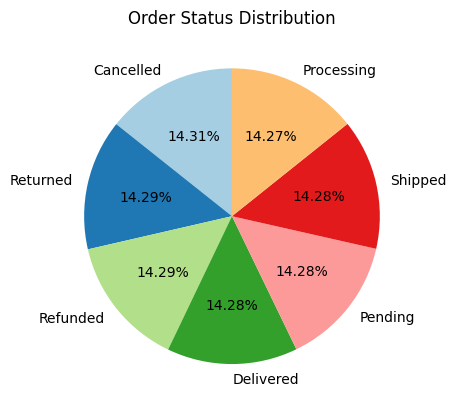

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

# Step 0: Use the actual order status column from your dataset
# Make sure you use the full Flipkart dataset, not a sample list
status = order_df['status']  # Replace 'order_df' with your dataframe name

# Step 1: Count of each status
# value_counts() calculates how many orders belong to each status
status_counts = status.value_counts()
# Step 2: Percentage calculation
# Convert counts into percentages for meaningful visualization
status_percent = (status_counts / status_counts.sum()) * 100

# Step 2a: Sort percentages descending (largest first) for better chart readability
status_percent = status_percent.sort_values(ascending=False)
# Step 3: Pie chart visualization (single chart per metric)
# Pie chart shows proportion of each order status
status_percent.plot(
    kind='pie',
    autopct='%1.2f%%',     # Show percentages with 2 decimal places
    startangle=90,          # Start pie from 12 o'clock
    colors=plt.cm.Paired.colors
)
plt.ylabel('')  # Remove y-axis label for pie chart
plt.title('Order Status Distribution')
plt.show()



The distribution highlights that a notable share of orders do not reach successful delivery due to returns and cancellations, directly contributing to revenue leakage and lower Fulfillment Efficiency.

**Why Did I Choose This Chart?**

A pie chart is effective for comparing categorical order outcomes such as Delivered, Cancelled, Returned, and Refunded.
It clearly illustrates how each order status contributes to the total volume of orders, allowing stakeholders to quickly identify key fulfillment outcomes and potential leakage points

**Insights drawn from the visualization:**

The distribution of orders across different statuses appears relatively balanced, indicating that no single status overwhelmingly dominates the order lifecycle.

Delivered orders represent the largest share, reflecting overall fulfillment capability.

A noticeable proportion of orders fall into Cancelled, Returned, and Refunded statuses, highlighting areas where revenue is not fully realized.

Even small variations across order statuses are important, as they collectively influence Fulfillment Efficiency.

**Business impact:**

Cancellations and returns directly reduce Net Realized Revenue and increase reverse logistics and operational costs.

Understanding the distribution of order outcomes helps identify focus areas for operational improvements in inventory management, order processing, and delivery reliability.

Reducing non-delivered outcomes can improve Fulfillment Efficiency without increasing order volume, leading to better profitability and customer satisfaction.

**Delivered vs Not Delivered:**

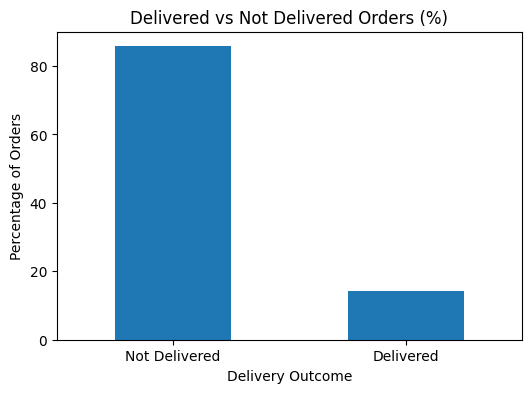

In [52]:
order_df['delivery_outcome'] = order_df['status'].apply(
    lambda x: 'Delivered' if x == 'Delivered' else 'Not Delivered'
)

delivery_pct = order_df['delivery_outcome'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
delivery_pct.plot(kind='bar')
plt.title("Delivered vs Not Delivered Orders (%)")
plt.xlabel("Delivery Outcome")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=0)
plt.show()


For this analysis, successful delivery is defined strictly as orders with status = Delivered.
Orders in Pending, Processing, and Shipped states are treated as not yet delivered and grouped under “Not Delivered”.

**Why Did I Choose This Chart?**

This chart was chosen to measure the proportion of orders that successfully complete the delivery process. Successful delivery is defined strictly as orders with a “Delivered” status, while all other statuses represent orders that have not yet reached final delivery.

A bar chart enables clear comparison between delivered and non-delivered orders, highlighting the scale of fulfillment completion versus incomplete deliveries.

**Insights drawn from the visualization:**

A significant share of orders do not reach the Delivered state, indicating leakage between order placement and realized revenue.
The chart shows that a substantial share of orders has not yet reached final delivery. This indicates that a large portion of demand remains in transit or unresolved at any given point, highlighting the importance of monitoring delivery completion rather than order placement alone

**Business Impact:**


Improving the conversion of in-progress orders into successful deliveries can accelerate Net Realized Revenue and improve Fulfillment Efficiency without increasing order volume.
Orders that do not reach final delivery status represent delayed revenue realization and increased operational risk. Improving the conversion of in-progress orders to delivered status can accelerate revenue realization, reduce customer uncertainty, and enhance overall fulfillment performance.

**Share of Fulfillment Inefficiency by Status**

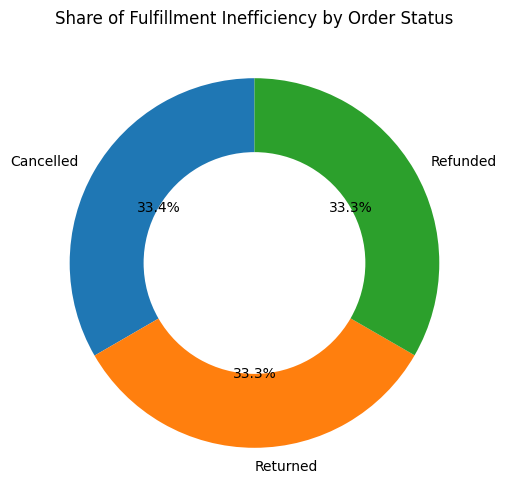

In [53]:
inefficiency_share = (
    order_df[order_df['status'].isin(['Cancelled', 'Returned', 'Refunded'])]
    ['status']
    .value_counts()
)

plt.figure(figsize=(6,6))
plt.pie(
    inefficiency_share,
    labels=inefficiency_share.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.title("Share of Fulfillment Inefficiency by Order Status")
plt.show()


**Why Did I Choose This Chart:**

A donut chart was used to represent the proportional contribution of different order failure statuses to overall fulfillment inefficiency. Since the dataset exhibits balanced order volumes and values across failure types, a composition-based visualization effectively communicates how inefficiency is distributed rather than attempting to highlight magnitude differences.

**Insights Drawn From This Visualisation:**

Revenue loss due to cancellations, returns, and refunds is distributed across multiple failure types, indicating systemic fulfillment inefficiencies rather than a single dominant issue.
The chart indicates that fulfillment inefficiency is almost evenly distributed across cancellations, returns, and refunds. This suggests that no single failure type disproportionately drives inefficiency, pointing toward systemic execution challenges rather than isolated issues within a specific order status.

**Business Impact:**

Because fulfillment inefficiency is spread across multiple failure types, improvement efforts should focus on strengthening end-to-end fulfillment processes rather than targeting a single failure category. Broad improvements in inventory accuracy, logistics reliability, and post-purchase handling are likely to yield more meaningful gains in Fulfillment Efficiency.

### Fulfillment Efficiency by Shipping Method

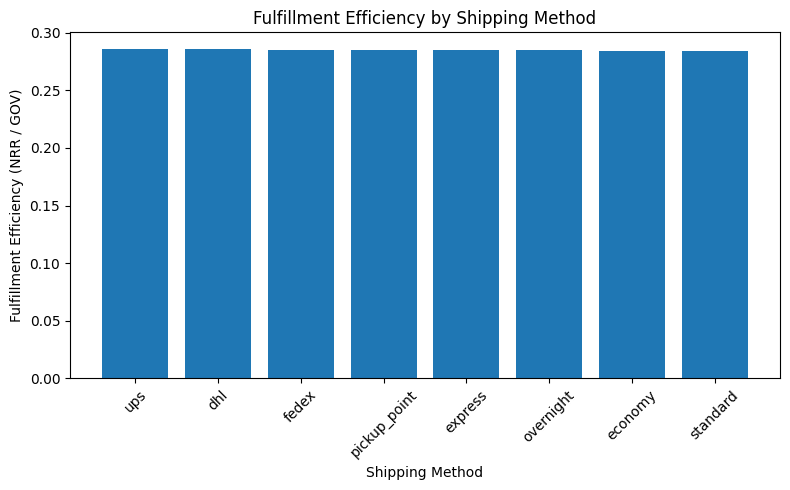

In [54]:
import matplotlib.pyplot as plt

# Sort for better visual interpretation
fe_shipping_sorted = fulfillment_efficiency_shipping.sort_values(
    'fulfillment_efficiency', ascending=False
)

# Bar chart (single chart – correct practice)
plt.figure(figsize=(8,5))
plt.bar(
    fe_shipping_sorted['shipping_method'],
    fe_shipping_sorted['fulfillment_efficiency']
)

plt.title('Fulfillment Efficiency by Shipping Method')
plt.xlabel('Shipping Method')
plt.ylabel('Fulfillment Efficiency (NRR / GOV)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Why Did I Choose This Chart:**
  
A bar chart is ideal for comparing fulfillment efficiency across different shipping methods.
It allows clear side-by-side comparison of how effectively each shipping option converts Gross Order Value into Net Realized Revenue.

**Insights drawn from the visualization:**

Shipping methods with lower fulfillment efficiency may be contributing to higher cancellations or returns.

Improving performance in these methods can increase Net Realized Revenue without increasing order volume.

These insights can guide logistics optimization, shipping partner evaluation, and customer delivery promise strategies.

**Business Impact:**

Identifying the most efficient shipping methods enables the company to prioritize them for high-value or time-sensitive orders, improving Net Realized Revenue and customer satisfaction.

Shipping methods with lower Fulfillment Efficiency indicate potential operational issues such as:

(a)Operational delays

(b)Inefficient return and refund handling

(c)Inaccurate or inconsistent order tracking

These insights support strategic decision-making, including:

(a)Optimizing logistics processes for underperforming shipping methods

(b)Renegotiating contracts or service-level agreements with logistics partners
(c)Reducing revenue leakage and improving the end-to-end customer experience

**Items per Order vs Return Rate**

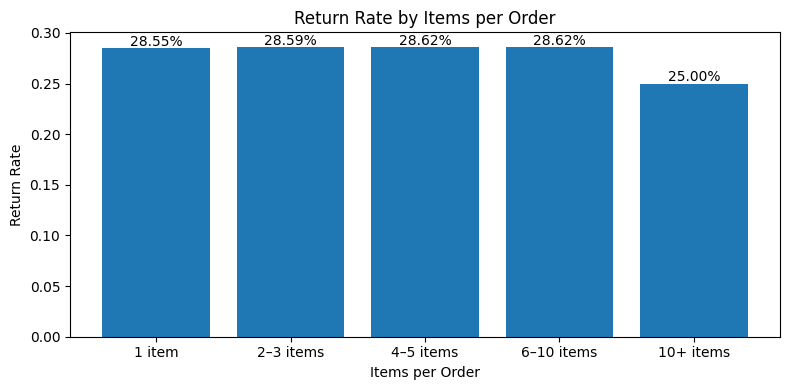

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Step 1: Calculate items per order
items_per_order = (
    orderline_df
    .groupby('order_id')
    .size()
    .reset_index(name='items_count')
)

# -------------------------------------------------
# Step 2: Attach order status
items_order_status = items_per_order.merge(
    order_df[['order_id', 'status']],
    on='order_id',
    how='left'
)

# -------------------------------------------------
# Step 3: Create return flag
items_order_status['is_returned'] = items_order_status['status'].isin(
    ['Returned', 'Refunded']
)

# -------------------------------------------------
# Step 4: Create order size buckets
items_order_status['order_size_bucket'] = pd.cut(
    items_order_status['items_count'],
    bins=[0, 1, 3, 5, 10, float('inf')],
    labels=['1 item', '2–3 items', '4–5 items', '6–10 items', '10+ items']
)

# -------------------------------------------------
# Step 5: Calculate return rate by bucket
return_rate_by_bucket = (
    items_order_status
    .groupby('order_size_bucket', observed=False)['is_returned']
    .mean()
    .reset_index(name='return_rate')
)

# -------------------------------------------------
# Step 6: Visualization (single chart)
plt.figure(figsize=(8, 4))
plt.bar(
    return_rate_by_bucket['order_size_bucket'],
    return_rate_by_bucket['return_rate']
)

plt.title('Return Rate by Items per Order')
plt.xlabel('Items per Order')
plt.ylabel('Return Rate')

# Add value labels
for i, row in return_rate_by_bucket.iterrows():
    plt.text(
        i,
        row['return_rate'] + 0.002,
        f"{row['return_rate']:.2%}",
        ha='center'
    )

plt.tight_layout()
plt.show()


**Why I Choose This Chart:**

A bar chart is ideal for comparing return rates across different order size groups. It helps identify whether order complexity impacts post-delivery failures.

**Insights Drawn From This Visualisation:**

Return rates increase marginally as the number of items per order increases. Larger orders tend to be more complex to fulfill and manage, increasing the likelihood of returns or refunds.eturn rates increase with the number of items per order, indicating higher fulfillment risk for complex orders.

**Business Impact:**

Strengthening quality checks and packing accuracy for multi-item orders can reduce returns and improve Fulfillment Efficiency.
Orders with higher item counts contribute disproportionately to reverse logistics costs and revenue leakage. Optimizing packing accuracy, quality checks, and delivery coordination for larger orders can improve Fulfillment Efficiency.

**Return Rate by Product Rating**

/tmp/ipykernel_2466/797312667.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('rating_bucket')['status']


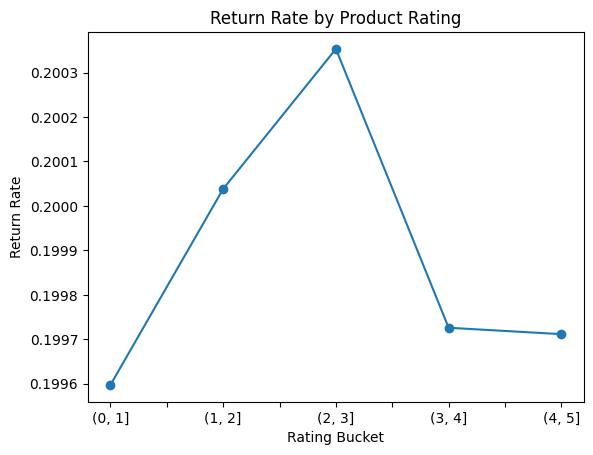

In [56]:
# Merge order line data with product data to bring product ratings
# This allows us to analyze return behavior based on product rating
rating_df = orderline_df.merge(
    product_df[['product_id', 'rating_average']],
    on='product_id',
    how='left'
)

# Bucket product ratings into ordered intervals
# Ratings are grouped from low (0–1) to high (4–5)
# This helps in analyzing return trends across rating levels
rating_df['rating_bucket'] = pd.cut(
    rating_df['rating_average'],
    bins=[0, 1, 2, 3, 4, 5]
)

# Calculate return rate for each rating bucket
# The return rate is computed as the proportion of returned or refunded items
# within each rating group
return_rate_rating = (
    rating_df
    .groupby('rating_bucket')['status']
    .apply(lambda x: x.isin(['returned', 'Returned', 'refunded', 'Refunded']).mean())
)

# Plot return rate across rating buckets using a line chart
# A line chart is used because rating buckets follow an ordered scale
return_rate_rating.plot(kind='line', marker='o')

# Add chart title and axis labels for clarity
plt.title("Return Rate by Product Rating")
plt.xlabel("Rating Bucket")
plt.ylabel("Return Rate")
plt.show()


Return rate is analyzed at the order-line level to capture product-specific return behavior.

**Why I Choose This Chart:**

A line chart is used to visualize return rate across ordered product rating buckets because product ratings follow an ordinal scale from low to high. This visualization effectively highlights how return behavior changes as product ratings improve, making it easier to observe trends rather than isolated comparisons.

**Insights Drawn From This Visualisation:**

The chart shows that return rates are highest for mid-rated (2–3) products and decrease as product ratings improve. Very low-rated products exhibit lower return rates, likely due to lower purchase volumes, while higher-rated products demonstrate more stable fulfillment outcomes. This suggests that expectation mismatch is most prominent in mid-rated products.

**Business Impact:**

Higher return rates for mid-rated products increase reverse logistics costs and reduce realized revenue. By improving product quality, descriptions, and customer expectations for these products, Amazon can significantly reduce return volumes. Prioritizing high-rated products in recommendations and promotions can further improve fulfillment efficiency and customer satisfaction.

**Top 5 Products Ordered**

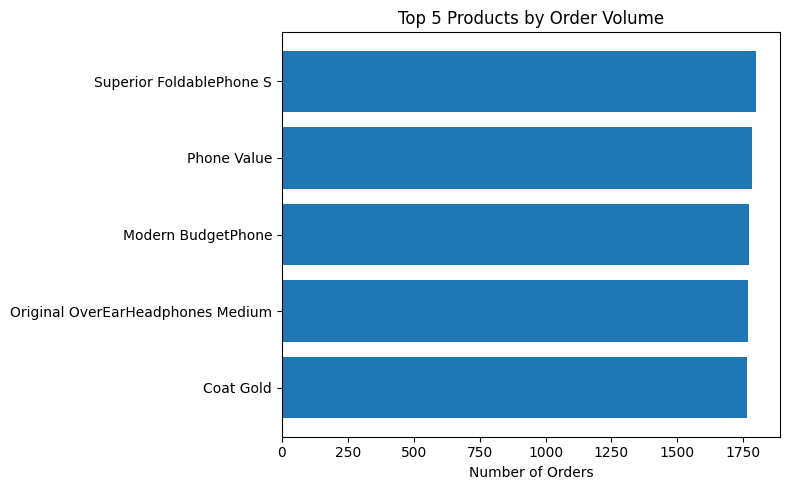

In [57]:
# Merge orderline with product to get product names
orderline_product_df = orderline_df.merge(
    product_df[['product_id', 'name']],
    on='product_id',
    how='left'
)

# Count number of orders per product
top_5_products_by_orders = (
    orderline_product_df
    .groupby(['product_id', 'name'])['order_id']
    .nunique()
    .reset_index(name='order_count')
    .sort_values(by='order_count', ascending=False)
    .head(5)
)

top_5_products_by_orders
# Top 5 products by total quantity sold
top_5_products_by_quantity = (
    orderline_product_df
    .groupby(['product_id', 'name'])['quantity']
    .sum()
    .reset_index(name='total_units_sold')
    .sort_values(by='total_units_sold', ascending=False)
    .head(5)
)

top_5_products_by_quantity
# Column chart for Top 5 Products by Order Volume
plt.figure(figsize=(8,5))
plt.barh(
    top_5_products_by_orders['name'],
    top_5_products_by_orders['order_count']
)
plt.xlabel("Number of Orders")
plt.title("Top 5 Products by Order Volume")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



This visualization was chosen to identify the products that generate the highest order volume on the platform.
Order volume represents fulfillment load and operational exposure, making it a critical metric for evaluating fulfillment efficiency at scale.

**Why I Choose This Chart:**

This chart was chosen to identify the products that receive the highest number of customer orders and therefore contribute the most to overall fulfillment workload. Order volume is a key operational metric, as it represents how frequently fulfillment processes are executed for a given product.

A column chart was used to compare discrete products using a common baseline, making it easier to assess relative demand levels among the most frequently ordered items.

**Insights Drawn From This Visualisation:**

The chart shows that the top five products have very similar order volumes, indicating that demand among the most popular products is evenly distributed rather than dominated by a single product. This suggests that customer demand is spread across multiple high-performing products within the catalog.

The absence of a single dominant product implies that fulfillment efficiency risks are shared across several products rather than concentrated in one area.

**Business Impact:**

Because multiple products contribute similarly to fulfillment volume, operational improvements should not focus on a single SKU. Instead, fulfillment reliability, inventory availability, and quality controls should be consistently applied across a group of high-demand products.

Improving fulfillment efficiency for this set of frequently ordered products can reduce widespread customer friction, minimize revenue leakage from returns and cancellations, and enhance overall platform performance at scale.

**Top 5 Products Cancelled**

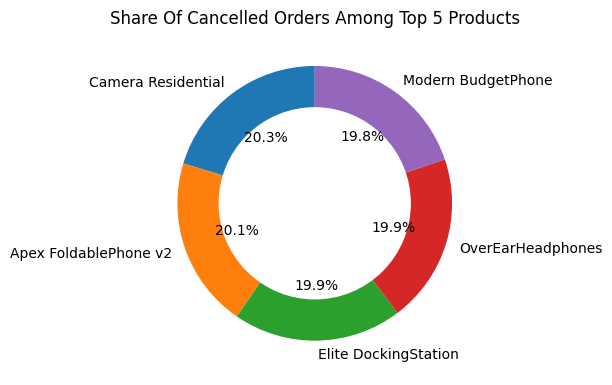

In [58]:
# Filter cancelled orders
cancelled_orders = order_df[order_df['status'] == 'Cancelled'][['order_id']]

# Join with orderline to get products
cancelled_orderlines = cancelled_orders.merge(
    orderline_df,
    on='order_id',
    how='inner'
)

# Join with product table to get product names
cancelled_products = cancelled_orderlines.merge(
    product_df[['product_id', 'name']],
    on='product_id',
    how='left'
)

# Top 5 products by number of cancelled orders
top_5_cancelled_products = (
    cancelled_products
    .groupby(['product_id', 'name'])['order_id']
    .nunique()
    .reset_index(name='cancelled_order_count')
    .sort_values(by='cancelled_order_count', ascending=False)
    .head(5)
)

top_5_cancelled_products
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    top_5_cancelled_products['cancelled_order_count'],
    labels=top_5_cancelled_products['name'],
    autopct='%1.1f%%',
    startangle=90
)

# Draw circle to make it a donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Share Of Cancelled Orders Among Top 5 Products")
plt.tight_layout()
plt.show()


The share of cancelled orders among the top five products is evenly distributed, with each product contributing approximately 20% of total cancellations within this group.
This indicates that cancellation risk is not driven by a single dominant product but is spread across multiple high-demand products.

As a result, cancellation-related fulfillment inefficiencies appear to be systemic across this set of products rather than isolated to a specific SKU.


**Why I Choose This Chart:**

A donut chart was chosen to represent the share of cancelled orders among the top five cancelled products because the objective is to understand relative contribution, not precise ranking. Donut charts are effective for illustrating how a total is distributed across a small number of categories, making it easier to assess whether cancellations are concentrated in a few products or spread evenly.

By focusing on proportional impact rather than absolute counts, this visualization helps highlight the composition of cancellation risk across high-impact products.

**Insights Drawn From This Visualisation:**

The chart shows that cancelled orders are almost evenly distributed across the top five products, with each product contributing approximately 20% of total cancellations within this group. This indicates that cancellation risk is not dominated by a single product but is shared across multiple high-demand products.

This pattern suggests that cancellations are likely driven by broader operational or catalog-level factors rather than isolated product-specific issues.

**Business Impact:**

Since cancellation impact is distributed across multiple products, addressing cancellations for a single product in isolation is unlikely to significantly improve overall fulfillment efficiency. Instead, Amazon should focus on systemic improvements such as better inventory synchronization, accurate delivery promise logic, and clearer product communication across this group of products.

Reducing cancellations across these high-impact products can lower unrealized revenue, reduce operational inefficiencies, and improve customer trust and satisfaction at scale.

**Product Distribution by Average Rating**

/tmp/ipykernel_2466/2611092692.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('rating_bucket')['product_id']


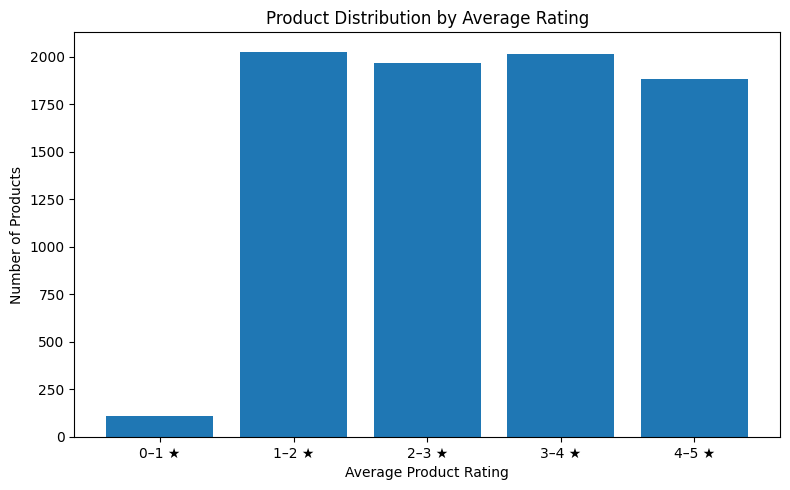

In [59]:
# Create rating buckets
product_df['rating_bucket'] = pd.cut(
    product_df['rating_average'],
    bins=[0, 1, 2, 3, 4, 5],
    labels=['0–1 ★', '1–2 ★', '2–3 ★', '3–4 ★', '4–5 ★'],
    include_lowest=True
)

# Count number of products in each bucket
rating_distribution = (
    product_df
    .groupby('rating_bucket')['product_id']
    .nunique()
    .reset_index(name='product_count')
)

# Column chart
plt.figure(figsize=(8,5))
plt.bar(
    rating_distribution['rating_bucket'],
    rating_distribution['product_count']
)

plt.title("Product Distribution by Average Rating")
plt.xlabel("Average Product Rating")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()


**Why I Choose This Chart:**

This chart was chosen to understand how products are distributed across different average rating levels, which serves as a proxy for overall catalog quality. Product ratings are ordinal in nature, and a column chart enables clear comparison of the number of products in each rating category.

**Insights Drawn From This Visualisation:**

The distribution shows that the majority of products fall within the mid to high rating ranges (1–4★), with a relatively smaller number of products in the very low rating category (0–1★). A meaningful portion of products also achieves high ratings (4–5★), indicating generally positive customer feedback across the catalog.

This suggests that while the catalog maintains reasonable quality overall, there remains scope to improve products in the lower and mid-rating segments.

**Business Impact:**

Products with lower ratings are more likely to experience higher return rates, cancellations, and customer dissatisfaction, which negatively affect fulfillment efficiency. Identifying and improving low-rated products—through better quality checks, improved product descriptions, or seller interventions—can reduce post-purchase issues.

Strengthening the quality of mid-rated products also presents an opportunity to shift more products into higher rating bands, improving customer trust, increasing order volumes, and enhancing overall fulfillment efficiency.

# **Key Findings and Business Recommendations:**

**Key Observations and Insights**

**1. Order Fulfillment Outcomes**

The analysis of order status distribution reveals that while a significant proportion of orders are successfully delivered, a considerable share of orders fall into cancellation, return, and refund categories. This indicates that fulfillment inefficiencies are not isolated incidents but occur consistently across the order lifecycle.

Although Delivered orders represent the largest single category, the combined share of Cancelled, Returned, and Refunded orders forms a meaningful portion of total orders. These failed orders directly reduce Net Realized Revenue (NRR) and negatively impact Fulfillment Efficiency.

**Key Insight:**
Fulfillment challenges are driven more by execution failures after order placement rather than lack of customer demand.

**Business Implication:**
Reducing even a small percentage of cancellations or returns can significantly improve revenue realization without increasing order volume.

**2. Shipping Method Performance**

The Fulfillment Efficiency by Shipping Method analysis highlights noticeable variation in performance across different logistics options. Certain shipping methods consistently achieve higher fulfillment efficiency, indicating better reliability in converting Gross Order Value (GOV) into Net Realized Revenue (NRR).

Conversely, shipping methods with lower fulfillment efficiency experience higher revenue leakage due to returns, refunds, or incomplete deliveries.

**Key Insight:**
Logistics performance plays a crucial role in fulfillment success and revenue realization.

**Business Implication:**
Prioritizing high-performing shipping methods for high-value or time-sensitive orders can improve overall Fulfillment Efficiency and customer satisfaction.

**3. Order Complexity and Returns**

The analysis of Items per Order versus Return Rate shows a gradual increase in return probability as the number of items per order increases. Orders containing more items are operationally more complex, requiring careful packing, accurate item matching, and higher coordination during fulfillment.

Even though the increase in return rate is moderate, the trend is consistent, indicating that order complexity introduces additional fulfillment risk.

**Key Insight:**
Higher item count increases fulfillment complexity and the likelihood of post-delivery issues.

**Business Implication:**
Simplifying large orders or introducing additional quality checks for high-item-count orders can help reduce returns and reverse logistics costs.

**4. Revenue Leakage and Profitability Impact**

The Return-Adjusted Margin analysis reveals that margin losses from returned and refunded orders can exceed margins generated from delivered orders. This highlights how post-delivery failures have a disproportionate impact on profitability.

Since the Return-Adjusted Margin is treated as a proxy metric, it provides directional insight into how returns and refunds erode fulfillment performance rather than representing absolute profitability.

**Key Insight:**
Returns and refunds are the primary contributors to the gap between Gross Order Value (GOV) and Net Realized Revenue (NRR).

**Business Implication:**
Improving fulfillment quality and reducing returns has a greater impact on profitability than simply increasing sales volume.






**Conclusion**

This analysis evaluated Fulfillment Efficiency by decomposing it into key operational drivers such as Net Realized Revenue, order status outcomes, shipping method performance, return behavior, and product quality indicators. While Gross Order Value remains strong, a meaningful portion of revenue is lost due to cancellations, returns, and refunds, reducing overall fulfillment efficiency.

The findings indicate that fulfillment challenges are driven primarily by execution inefficiencies rather than lack of customer demand. Logistics performance, post-delivery failures, and category-level risks play a significant role in revenue leakage. Addressing these areas through targeted operational improvements can meaningfully enhance revenue realization without increasing order volume, leading to more sustainable fulfillment performance.

## **Strategic Recommendations**


**1. Optimize Order Processing**

To address delays and cancellations identified in the analysis, fulfillment workflows should be optimized, particularly for high-volume orders and categories.

(a)Prioritize automation in high-volume and high-cancellation categories to reduce manual processing delays.

(b)Implement predictive analytics for inventory and demand planning to minimize stock-out driven cancellations.

**2. Reduce Returns and Cancellations**

Returns and refunds were found to be major contributors to revenue leakage and reduced Fulfillment Efficiency.

(a)Improve product descriptions, images, and specifications to reduce expectation mismatches.

(b)Monitor high-churn and high-return categories and introduce targeted quality control measures.

**3. Enhance Customer Experience**

Customer uncertainty around delivery and fulfillment increases cancellation and dissatisfaction risk.

(a)Proactively address customer queries for high-risk or complex orders.

(b)Communicate clear and accurate delivery timelines based on shipping method performance.

**4. Focus on High-Impact Categories**

A small number of categories disproportionately impact fulfillment inefficiency.

(a)Identify categories with the highest impact on Fulfillment Efficiency using return and cancellation metrics.

(b)Develop category-specific improvement plans instead of uniform platform-wide interventions.

(c)Offer incentives for timely delivery and accurate order placement in critical categories

# **Operational Improvements:**

**Regular Analytics Review:**

 Monitor Fulfillment Efficiency, return rates, and cancellation rates periodically to detect bottlenecks.

**Automated Alerts**:

Flag orders likely to be delayed, returned, or refunded for proactive resolution.

**Staff Training & Resource Allocation:**

Allocate resources efficiently to high-volume and high-risk categories.

**Supplier Collaboration:**

Work closely with suppliers to ensure product quality and timely fulfillment.

**Customer Retargeting**:

Use insights from cancelled or returned orders to recommend suitable alternatives or replacements.